In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



# Mount your Google Drive so files are accessible from Colab
from google.colab import drive
drive.mount('/content/drive')
print("Drive mounted successfully!")
FILE_PATH = '/content/drive/MyDrive/ColabNotebooks/CariSurg_Triage_Test/EmergencyTriageDataset_Reduced_Dirty.csv'

FILE_PATH = 'EmergencyTriageDataset_Reduced_Dirty.csv'

df = pd.read_csv(FILE_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted successfully!


In [2]:
gender_map = {
    'Male': 1, 'MALE': 1, '1': 1,
    'Female': 0, 'FEMALE': 0, '0': 0
}

df['Gender'] = df['Gender'].map(gender_map)

print(df.shape)
print(df.head())

(2205, 11)
   ID  Age  Gender   GCS  SBP    DBP     MAP  pulse  Temp    RR   Fio2
0   1   34       0  15.0   93   67.0   75.67  128.0  36.8  14.0   21.0
1   2   20       1  15.0  130   90.0  103.33   80.0  37.0  16.0   21.0
2   3   77       0  14.0  163  105.0  124.33   92.0  36.8  18.0   21.0
3   4   23       0   8.0  100   60.0   73.33  100.0  37.0  12.0  100.0
4   5   86       0  15.0  150   90.0  110.00   85.0  37.0  19.0   21.0


In [3]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2205 entries, 0 to 2204
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      2205 non-null   int64  
 1   Age     2205 non-null   int64  
 2   Gender  2205 non-null   int64  
 3   GCS     2183 non-null   object 
 4   SBP     2205 non-null   object 
 5   DBP     2183 non-null   float64
 6   MAP     2183 non-null   float64
 7   pulse   2183 non-null   object 
 8   Temp    2183 non-null   object 
 9   RR      2183 non-null   float64
 10  Fio2    2183 non-null   float64
dtypes: float64(4), int64(3), object(4)
memory usage: 189.6+ KB
None
                ID          Age       Gender          DBP          MAP  \
count  2205.000000  2205.000000  2205.000000  2183.000000  2183.000000   
mean   1154.987755    61.829478     0.533333    77.479615    93.912277   
std     677.167364    18.485363     0.499001    16.713289    19.006296   
min       1.000000    18.000000     0.000000   

GCS


In [4]:
print("GCS dtype:", df['GCS'].dtype)
print("Unique GCS values:", df['GCS'].unique())

GCS dtype: object
Unique GCS values: ['15.0' '14.0' '8.0' '13.0' '12.0' '10.0' 'error' nan '7.0' '9.0' '11.0'
 '6.0' '3.0']


In [5]:
# pd.to_numeric() with errors='coerce' converts numbers and turns
# everything non-numeric (like 'error') into NaN
df['GCS'] = pd.to_numeric(df['GCS'], errors='coerce')

print("After conversion:")
print(f"  dtype: {df['GCS'].dtype}")
print(f"  NaN count: {df['GCS'].isnull().sum()}")
print(f"  Range: {df['GCS'].min()} to {df['GCS'].max()}")


After conversion:
  dtype: float64
  NaN count: 44
  Range: 3.0 to 15.0


In [6]:
# Step 2: Flag physiologically impossible values
# GCS valid range: 3–15
invalid_gcs = df[(df['GCS'] < 3) | (df['GCS'] > 15)]
print(f"GCS values outside valid range (3–15): {len(invalid_gcs)} rows")
print(invalid_gcs[['ID', 'GCS']].head(10))

GCS values outside valid range (3–15): 0 rows
Empty DataFrame
Columns: [ID, GCS]
Index: []


In [7]:
# Step 3: Replace invalid values with NaN
df.loc[(df['GCS'] < 3) | (df['GCS'] > 15), 'GCS'] = np.nan
print(f"NaN count after range filter: {df['GCS'].isnull().sum()}")

NaN count after range filter: 44


In [8]:
# Compute the median and use it to fill NaN values
gcs_median = df['GCS'].median()
print(f"GCS median (before imputation): {gcs_median}")

df['GCS'] = df['GCS'].fillna(gcs_median)

print(f"GCS after imputation:")
print(df['GCS'].describe())
print(f"Remaining NaNs: {df['GCS'].isnull().sum()}")

GCS median (before imputation): 15.0
GCS after imputation:
count    2205.000000
mean       14.425850
std         1.375031
min         3.000000
25%        15.000000
50%        15.000000
75%        15.000000
max        15.000000
Name: GCS, dtype: float64
Remaining NaNs: 0


SBP

In [9]:
# SBP = Systolic Blood Pressure. Valid range: 50–250 mmHg.
# Extremely low SBP (<70) = shock risk. Extremely high (>200) = hypertensive crisis.

print("SBP unique values (sample):", df['SBP'].unique()[:15])
print("SBP dtype:", df['SBP'].dtype)

df['SBP'] = pd.to_numeric(df['SBP'], errors='coerce')
print("After type conversion:")
print(df['SBP'].describe())

invalid_sbp = df[(df['SBP'] < 50) | (df['SBP'] > 250)]
print(f"Out-of-range SBP rows: {len(invalid_sbp)}")
print(invalid_sbp[['ID', 'SBP']].head())

df.loc[(df['SBP'] < 50) | (df['SBP'] > 250), 'SBP'] = np.nan
sbp_median = df['SBP'].median()
df['SBP'] = df['SBP'].fillna(sbp_median)

print(f"SBP after cleaning: min={df['SBP'].min()}, max={df['SBP'].max()}, NaNs={df['SBP'].isnull().sum()}")


SBP unique values (sample): ['93' '130' '163' '100' '150' '120' '110' '153' '152' '186' '107' '80'
 '75' '58' '140']
SBP dtype: object
After type conversion:
count    2183.000000
mean      128.388456
std        43.881583
min        30.000000
25%       110.000000
50%       125.000000
75%       140.000000
max       500.000000
Name: SBP, dtype: float64
Out-of-range SBP rows: 44
      ID    SBP
29    32   30.0
111  123  500.0
168  183  500.0
231  247   30.0
275  291  500.0
SBP after cleaning: min=55.0, max=250.0, NaNs=0


Temperature

In [10]:
# First, look at the raw values
print("Temp unique values (sample):")
print(df['Temp'].unique()[:20])


Temp unique values (sample):
['36.8' '37.0' '36.5' '39.0' '37.3' '36.7' '37.8' '38.5' '38.0' '37.6'
 '38.2' '37C' '36.2' '37.2' '37.5' nan '36.9' '39.6' '37.4' '50']


In [11]:
# Write a function to standardise everything to Celsius
def to_celsius(val):
    """Convert temperature value to Celsius float.
    Handles: plain numbers, strings ending in 'C', strings ending in 'F'.
    Returns NaN for anything unrecognisable.
    """
    if pd.isnull(val):
        return np.nan
    val_str = str(val).strip()
    try:
        if val_str.endswith('C'):
            return float(val_str[:-1])          # remove 'C', convert
        elif val_str.endswith('F'):
            return (float(val_str[:-1]) - 32) * 5 / 9  # Fahrenheit to Celsius
        else:
            return float(val_str)               # assume Celsius already
    except ValueError:
        return np.nan                           # anything else -> NaN

df['Temp'] = df['Temp'].apply(to_celsius)

print("After standardisation:")
print(df['Temp'].describe())

After standardisation:
count    2183.000000
mean       37.323683
std         1.334411
min        35.000000
25%        37.000000
50%        37.000000
75%        37.500000
max        50.000000
Name: Temp, dtype: float64


In [12]:
# Apply range filter: valid body temperature 32–43°C
df.loc[(df['Temp'] < 32) | (df['Temp'] > 43), 'Temp'] = np.nan

# Impute with median
temp_median = round(df['Temp'].median(), 1)
df['Temp'] = df['Temp'].fillna(temp_median)

print(f"Temp after cleaning: min={df['Temp'].min():.1f}, max={df['Temp'].max():.1f}, NaNs={df['Temp'].isnull().sum()}")

Temp after cleaning: min=35.0, max=41.7, NaNs=0


DBP

In [13]:
COLUMN = 'DBP'
VALID_MIN = 30
VALID_MAX = 150

print("Before cleaning:")
print(df[COLUMN].describe())

# convert to numeric
df[COLUMN] = pd.to_numeric(df[COLUMN], errors='coerce')

# remove invalid values
df.loc[(df[COLUMN] < VALID_MIN) | (df[COLUMN] > VALID_MAX), COLUMN] = np.nan

# impute missing values
dbp_median = df[COLUMN].median()
df[COLUMN] = df[COLUMN].fillna(dbp_median)

print("\nAfter cleaning:")
print(df[COLUMN].describe())

Before cleaning:
count    2183.000000
mean       77.479615
std        16.713289
min        30.000000
25%        70.000000
50%        78.000000
75%        87.000000
max       173.000000
Name: DBP, dtype: float64

After cleaning:
count    2205.000000
mean       77.367347
std        16.316160
min        30.000000
25%        70.000000
50%        78.000000
75%        87.000000
max       150.000000
Name: DBP, dtype: float64


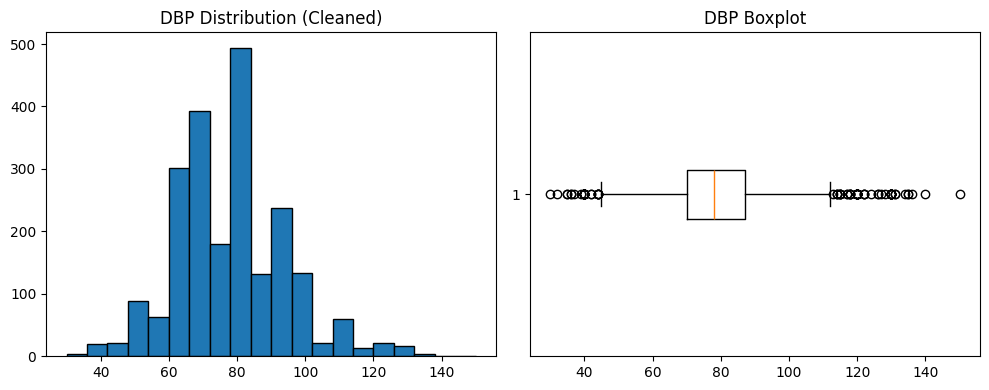

In [14]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.hist(df['DBP'], bins=20, edgecolor='black')
plt.title("DBP Distribution (Cleaned)")

plt.subplot(1,2,2)
plt.boxplot(df['DBP'], vert=False)
plt.title("DBP Boxplot")

plt.tight_layout()
plt.show()